# Bước 2: Data Collection, Understanding & Preparation
## UK Weather & Health: Weekly Deaths and Temperature (2016–2024)
---

## 2.1 Nguồn dữ liệu

| Nguồn | Dữ liệu | Phạm vi |
|---|---|---|
| **Met Office** | Nhiệt độ tối đa hàng ngày (tasmax) — tổng hợp trung bình UK | 2016–2024 |
| **ONS (Office for National Statistics)** | Số ca tử vong toàn nguyên nhân hàng tuần (England & Wales) | 2016–2024 |

- **Quy mô:** 442 bản ghi hàng tuần
- **File:** `uk_weather_health_weekly_2016_2024_TOTAL_FINAL.csv`
- **Data Dictionary:** `uk_weather_health_data_dictionary.csv`

## 2.2 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.


## 2.3 Load Dataset

In [2]:
# Load dataset chính
df = pd.read_csv('uk_weather_health_weekly_2016_2024_TOTAL_FINAL.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 442 rows × 6 columns


,week_start_sat,week_start_mon,week_end,deaths_total,tasmax_mean_weekly_degC,tasmax_max_weekly_degC
0,2016-01-02,2016-01-04,2016-01-08,13045.00,7.36,8.84
1,2016-01-09,2016-01-11,2016-01-15,11501.00,5.13,7.14
2,2016-01-16,2016-01-18,2016-01-22,11473.00,5.36,10.23
3,2016-01-23,2016-01-25,2016-01-29,11317.00,11.17,13.15
4,2016-01-30,2016-02-01,2016-02-05,11052.00,8.78,11.27
5,2016-02-06,2016-02-08,2016-02-12,11170.00,6.96,8.69
6,2016-02-13,2016-02-15,2016-02-19,10590.00,5.80,8.38
7,2016-02-20,2016-02-22,2016-02-26,11056.00,7.00,9.91
8,2016-02-27,2016-02-29,2016-03-04,11285.00,7.35,10.45
9,2016-03-05,2016-03-07,2016-03-11,11010.00,7.21,9.59


In [3]:
# Load data dictionary để tham khảo
data_dict = pd.read_csv('uk_weather_health_data_dictionary.csv')
data_dict

,dataset,column,meaning,unit
0,monthly,month_start,First day of month (YYYY-MM-DD) used as month ...,NaN
1,monthly,geography_level,Spatial level (provider or national).,NaN
2,monthly,geography_name,Provider name or national aggregate label.,NaN
3,monthly,ae_attendances_total,Total A&E attendances (sum across available at...,count
4,monthly,ae_over4hrs_total,Total attendances over 4 hours (sum across ava...,count
5,monthly,tasmax_mean_monthly_degC,Monthly mean of daily UK-average maximum tempe...,degC
6,monthly,tasmax_max_monthly_degC,Monthly maximum of daily UK-average maximum te...,degC
7,weekly,week_start,Monday of the week used as weekly index (YYYY-...,NaN
8,weekly,metric,Outcome metric name (currently weekly_deaths_a...,NaN
9,weekly,value,Weekly total deaths (all-cause) aggregated to ...,count


## 2.4 Kiểm tra sơ bộ dữ liệu

In [4]:
# Kiểu dữ liệu và số lượng non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   week_start_sat           442 non-null    object 
 1   week_start_mon           442 non-null    object 
 2   week_end                 442 non-null    object 
 3   deaths_total             442 non-null    float64
 4   tasmax_mean_weekly_degC  442 non-null    float64
 5   tasmax_max_weekly_degC   442 non-null    float64
dtypes: float64(3), object(3)
memory usage: 20.8+ KB


In [5]:
# Thống kê mô tả
df.describe()

,deaths_total,tasmax_mean_weekly_degC,tasmax_max_weekly_degC
count,442.00,442.00,442.00
mean,10790.34,13.33,15.54
std,1885.78,5.24,5.47
min,6825.00,0.96,2.47
25%,9651.50,8.95,11.06
50%,10536.00,13.04,15.11
75%,11507.75,17.88,19.73
max,22351.00,25.45,31.36


In [6]:
# Xem cuối bảng
df.tail()

,week_start_sat,week_start_mon,week_end,deaths_total,tasmax_mean_weekly_degC,tasmax_max_weekly_degC
437,2024-11-23,2024-11-25,2024-11-29,11011.00,9.72,14.03
438,2024-11-30,2024-12-02,2024-12-06,11510.00,11.38,13.24
439,2024-12-07,2024-12-09,2024-12-13,11951.00,5.75,6.94
440,2024-12-14,2024-12-16,2024-12-20,12636.00,10.24,12.86
441,2024-12-21,2024-12-23,2024-12-27,7151.00,9.13,12.05


In [7]:
# Tên cột & kiểu dữ liệu
print('Columns:', list(df.columns))
print('\nData types:')
print(df.dtypes)

Columns: ['week_start_sat', 'week_start_mon', 'week_end', 'deaths_total', 'tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC']

Data types:
week_start_sat              object
week_start_mon              object
week_end                    object
deaths_total               float64
tasmax_mean_weekly_degC    float64
tasmax_max_weekly_degC     float64
dtype: object


## 2.5 Kiểm tra dữ liệu thiếu (Missing Values)

Kiểm tra các cột `deaths_total`, `tasmax_mean_weekly_degC`, `tasmax_max_weekly_degC`.

In [8]:
# Kiểm tra missing values cho từng cột
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)
print(f'\nTổng số missing values: {df.isnull().sum().sum()}')

                         Missing Count  Missing %
week_start_sat                       0       0.00
week_start_mon                       0       0.00
week_end                             0       0.00
deaths_total                         0       0.00
tasmax_mean_weekly_degC              0       0.00
tasmax_max_weekly_degC               0       0.00

Tổng số missing values: 0


In [9]:
# Trực quan hóa missing values
if df.isnull().sum().sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
    ax.set_title('Missing Values Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print(' Không có giá trị null — dữ liệu khá sạch.')

 Không có giá trị null — dữ liệu khá sạch.


## 2.6 Kiểm tra bản ghi trùng lặp (Duplicates)

In [10]:
duplicates = df.duplicated().sum()
print(f'Số bản ghi trùng lặp: {duplicates}')

if duplicates > 0:
    print('Đang xóa bản ghi trùng...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape sau khi xóa: {df.shape}')
else:
    print(' Không có bản ghi trùng lặp.')

Số bản ghi trùng lặp: 0
 Không có bản ghi trùng lặp.


## 2.7 Mã hóa & Chuyển đổi kiểu dữ liệu

Chuyển đổi cột `week_start_mon` sang **DateTime** để trích xuất **Month**, **Year**, **Season**.

In [11]:
# Chuyển đổi các cột ngày sang datetime
date_cols = ['week_start_sat', 'week_start_mon', 'week_end']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print('Đã chuyển đổi cột ngày:')
print(df[date_cols].dtypes)
print(f'\nKhoảng thời gian: {df["week_start_mon"].min().date()} → {df["week_start_mon"].max().date()}')

Đã chuyển đổi cột ngày:
week_start_sat    datetime64[ns]
week_start_mon    datetime64[ns]
week_end          datetime64[ns]
dtype: object

Khoảng thời gian: 2016-01-04 → 2024-12-23


## 2.7.5 Xử lý đứt gãy Time Series (Interpolation)

Kiểm tra tính liên tục của chuỗi thời gian từ 2016-01-02 đến 2024-12-21 để đảm bảo không bị thiếu tuần nào (cần thiết cho mô hình ARIMA/Lag ở bước sau).

In [ ]:
# Kiểm tra và điền khuyết các tuần bị thiếu
df_ts = df.set_index("week_start_sat").sort_index()

# Tạo dải tuần hoàn chỉnh (mỗi thứ 7 hàng tuần)
expected_dates = pd.date_range(start=df_ts.index.min(), end=df_ts.index.max(), freq="W-SAT")
print(f"Số tuần kỳ vọng: {len(expected_dates)}")
print(f"Số tuần thực tế: {len(df_ts)}")
missing_weeks = len(expected_dates) - len(df_ts)
print(f"Số tuần bị thiếu: {missing_weeks}")

if missing_weeks > 0:
    print("\nĐang tiến hành Resample và Interpolate để điền khuyết...")
    
    # Đảm bảo index là datetime
    df_ts.index = pd.to_datetime(df_ts.index)
    
    # Giữ lại các cột cốt lõi để tính toán
    cols_to_keep = ["deaths_total", "tasmax_mean_weekly_degC", "tasmax_max_weekly_degC"]
    df_ts_clean = df_ts[cols_to_keep].copy()
    
    # Resample theo tuần (W-SAT) và Nội suy tuyến tính
    df_ts_resampled = df_ts_clean.resample("W-SAT").interpolate(method="linear")
    
    # Khôi phục lại DataFrame df
    df = df_ts_resampled.reset_index()
    # Tái tạo lại week_start_mon và week_end từ week_start_sat
    df["week_start_sat"] = df["week_start_sat"].dt.date
    df["week_start_mon"] = pd.to_datetime(df["week_start_sat"]) + pd.Timedelta(days=2)
    df["week_start_mon"] = df["week_start_mon"].dt.date
    df["week_end"] = pd.to_datetime(df["week_start_sat"]) + pd.Timedelta(days=6)
    df["week_end"] = df["week_end"].dt.date
    
    print(f"Đã điền khuyết xong. Shape mới: {df.shape}")
else:
    df = df_ts.reset_index()
    print("Chuỗi thời gian hoàn toàn liên tục.")

In [12]:
# Trích xuất Year, Month, Week, Quarter
df['year'] = df['week_start_mon'].dt.year
df['month'] = df['week_start_mon'].dt.month
df['week_of_year'] = df['week_start_mon'].dt.isocalendar().week.astype(int)
df['quarter'] = df['week_start_mon'].dt.quarter

# Tạo biến Season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# Biên độ nhiệt trong tuần
df['temp_range_weekly'] = df['tasmax_max_weekly_degC'] - df['tasmax_mean_weekly_degC']

print('Các biến mới được tạo:')
print(df[['year', 'month', 'week_of_year', 'quarter', 'season', 'temp_range_weekly']].head(10))

Các biến mới được tạo:
   year  month  week_of_year  quarter  season  temp_range_weekly
0  2016      1             1        1  Winter               1.48
1  2016      1             2        1  Winter               2.00
2  2016      1             3        1  Winter               4.87
3  2016      1             4        1  Winter               1.99
4  2016      2             5        1  Winter               2.49
5  2016      2             6        1  Winter               1.73
6  2016      2             7        1  Winter               2.59
7  2016      2             8        1  Winter               2.91
8  2016      2             9        1  Winter               3.09
9  2016      3            10        1  Spring               2.38


## 2.8 Tạo biến `IsSurge` (ScoreGroup 0/1)

Theo định nghĩa ở Bước 1:
- **1:** `deaths_total` > ngưỡng **75th percentile** → đợt bùng phát tử vong
- **0:** Mức bình thường

In [13]:
# Tính ngưỡng 75th percentile
threshold_75 = df['deaths_total'].quantile(0.75)
print(f'Ngưỡng 75th percentile: {threshold_75:.0f} deaths/week')

# Tạo biến IsSurge
df['IsSurge'] = (df['deaths_total'] > threshold_75).astype(int)

print(f'\nPhân bố IsSurge:')
print(df['IsSurge'].value_counts())
print(f'\nTỷ lệ: Surge = {df["IsSurge"].mean()*100:.1f}%, Normal = {(1-df["IsSurge"].mean())*100:.1f}%')

Ngưỡng 75th percentile: 11508 deaths/week

Phân bố IsSurge:
IsSurge
0    331
1    111
Name: count, dtype: int64

Tỷ lệ: Surge = 25.1%, Normal = 74.9%


## 2.9 Phân bố dữ liệu (Distribution — Histogram)

- Nhiệt độ có phân bố chuẩn không?
- Số ca tử vong có bị lệch (skewed) do các đợt dịch không?

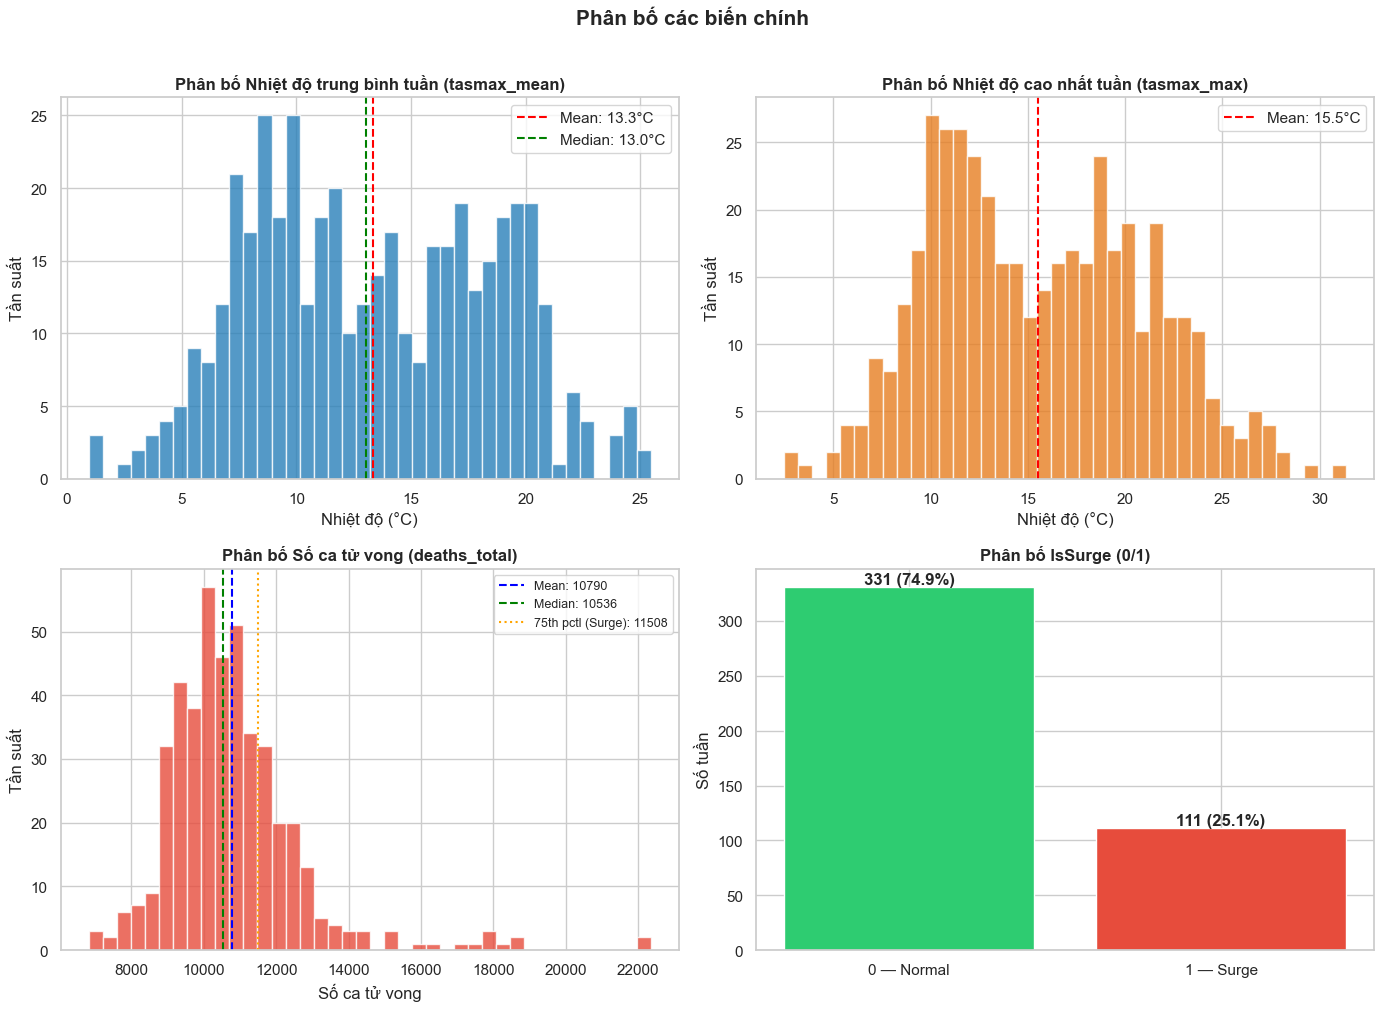

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram — Nhiệt độ trung bình tuần
axes[0, 0].hist(df['tasmax_mean_weekly_degC'], bins=40, color='#2980b9', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(df['tasmax_mean_weekly_degC'].mean(), color='red', linestyle='--',
                    label=f'Mean: {df["tasmax_mean_weekly_degC"].mean():.1f}°C')
axes[0, 0].axvline(df['tasmax_mean_weekly_degC'].median(), color='green', linestyle='--',
                    label=f'Median: {df["tasmax_mean_weekly_degC"].median():.1f}°C')
axes[0, 0].set_title('Phân bố Nhiệt độ trung bình tuần (tasmax_mean)', fontweight='bold')
axes[0, 0].set_xlabel('Nhiệt độ (°C)')
axes[0, 0].set_ylabel('Tần suất')
axes[0, 0].legend()

# 2. Histogram — Nhiệt độ cao nhất tuần
axes[0, 1].hist(df['tasmax_max_weekly_degC'], bins=40, color='#e67e22', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(df['tasmax_max_weekly_degC'].mean(), color='red', linestyle='--',
                    label=f'Mean: {df["tasmax_max_weekly_degC"].mean():.1f}°C')
axes[0, 1].set_title('Phân bố Nhiệt độ cao nhất tuần (tasmax_max)', fontweight='bold')
axes[0, 1].set_xlabel('Nhiệt độ (°C)')
axes[0, 1].set_ylabel('Tần suất')
axes[0, 1].legend()

# 3. Histogram — Số ca tử vong
axes[1, 0].hist(df['deaths_total'], bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(df['deaths_total'].mean(), color='blue', linestyle='--',
                    label=f'Mean: {df["deaths_total"].mean():.0f}')
axes[1, 0].axvline(df['deaths_total'].median(), color='green', linestyle='--',
                    label=f'Median: {df["deaths_total"].median():.0f}')
axes[1, 0].axvline(threshold_75, color='orange', linestyle=':',
                    label=f'75th pctl (Surge): {threshold_75:.0f}')
axes[1, 0].set_title('Phân bố Số ca tử vong (deaths_total)', fontweight='bold')
axes[1, 0].set_xlabel('Số ca tử vong')
axes[1, 0].set_ylabel('Tần suất')
axes[1, 0].legend(fontsize=9)

# 4. Histogram — IsSurge
colors_surge = ['#2ecc71', '#e74c3c']
surge_counts = df['IsSurge'].value_counts().sort_index()
axes[1, 1].bar(['0 — Normal', '1 — Surge'], surge_counts.values, color=colors_surge, edgecolor='white')
for i, v in enumerate(surge_counts.values):
    axes[1, 1].text(i, v + 3, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1, 1].set_title('Phân bố IsSurge (0/1)', fontweight='bold')
axes[1, 1].set_ylabel('Số tuần')

plt.suptitle('Phân bố các biến chính', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Kiểm tra skewness và kurtosis
check_cols = ['deaths_total', 'tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC']

print('Đánh giá phân bố:')
print('=' * 65)
for col in check_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    shape = 'Đối xứng (≈ chuẩn)' if abs(skew) < 0.5 else ('Lệch phải ↗' if skew > 0 else 'Lệch trái ↙')
    print(f'{col}:')
    print(f'  Skewness = {skew:.3f} → {shape}')
    print(f'  Kurtosis = {kurt:.3f}')
    print()

Đánh giá phân bố:
deaths_total:
  Skewness = 2.120 → Lệch phải ↗
  Kurtosis = 8.379

tasmax_mean_weekly_degC:
  Skewness = 0.102 → Đối xứng (≈ chuẩn)
  Kurtosis = -0.911

tasmax_max_weekly_degC:
  Skewness = 0.235 → Đối xứng (≈ chuẩn)
  Kurtosis = -0.676



## 2.10 Ngoại lệ (Outliers)

Hai loại outlier cần chú ý:
- **Nhiệt độ > 30°C** — các đợt nắng nóng bất thường
- **Tử vong > 20,000/tuần** — các đợt COVID-19

In [16]:
#  Outlier theo ngưỡng nghiệp vụ 
print('NGOẠI LỆ THEO NGƯỠNG NGHIỆP VỤ')
print('=' * 65)

# Nhiệt độ > 30°C
hot_weeks = df[df['tasmax_max_weekly_degC'] > 30]
print(f'\n Tuần có nhiệt độ max > 30°C: {len(hot_weeks)} tuần')
if len(hot_weeks) > 0:
    print(hot_weeks[['week_start_mon', 'tasmax_max_weekly_degC', 'tasmax_mean_weekly_degC', 'deaths_total', 'year']]
          .sort_values('tasmax_max_weekly_degC', ascending=False)
          .to_string(index=False))

# Tử vong > 20,000
high_death_weeks = df[df['deaths_total'] > 20000]
print(f'\n Tuần có tử vong > 20,000: {len(high_death_weeks)} tuần')
if len(high_death_weeks) > 0:
    print(high_death_weeks[['week_start_mon', 'deaths_total', 'tasmax_mean_weekly_degC', 'year']]
          .sort_values('deaths_total', ascending=False)
          .to_string(index=False))

NGOẠI LỆ THEO NGƯỠNG NGHIỆP VỤ

 Tuần có nhiệt độ max > 30°C: 1 tuần
week_start_mon  tasmax_max_weekly_degC  tasmax_mean_weekly_degC  deaths_total  year
    2022-07-18                   31.36                    24.54      10978.00  2022

 Tuần có tử vong > 20,000: 2 tuần
week_start_mon  deaths_total  tasmax_mean_weekly_degC  year
    2020-04-13      22351.00                    14.41  2020
    2020-04-20      21997.00                    15.96  2020


In [17]:
#  Outlier theo IQR 
print('NGOẠI LỆ THEO PHƯƠNG PHÁP IQR')
print('=' * 65)

for col in check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers')
    print(f'  Khoảng chấp nhận: [{lower:.2f}, {upper:.2f}]')
    print()

NGOẠI LỆ THEO PHƯƠNG PHÁP IQR
deaths_total: 18 outliers
  Khoảng chấp nhận: [6867.12, 14292.12]

tasmax_mean_weekly_degC: 0 outliers
  Khoảng chấp nhận: [-4.45, 31.29]

tasmax_max_weekly_degC: 0 outliers
  Khoảng chấp nhận: [-1.95, 32.73]



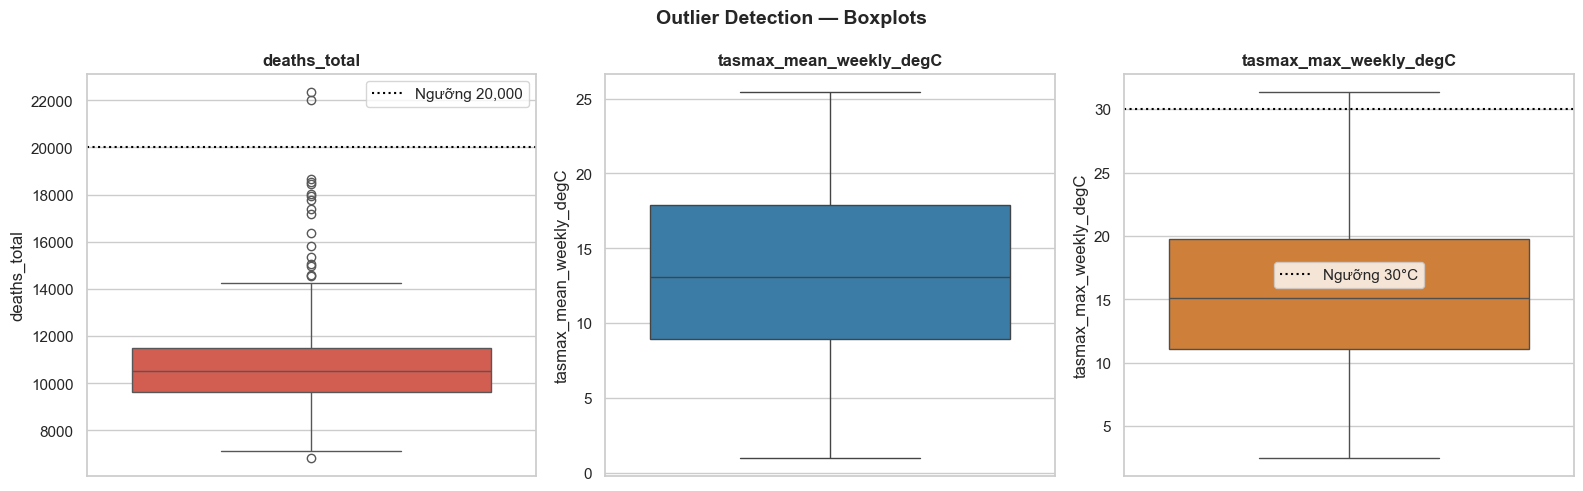

In [18]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df['deaths_total'], ax=axes[0], color='#e74c3c')
axes[0].axhline(20000, color='black', linestyle=':', label='Ngưỡng 20,000')
axes[0].set_title('deaths_total', fontweight='bold')
axes[0].legend()

sns.boxplot(y=df['tasmax_mean_weekly_degC'], ax=axes[1], color='#2980b9')
axes[1].set_title('tasmax_mean_weekly_degC', fontweight='bold')

sns.boxplot(y=df['tasmax_max_weekly_degC'], ax=axes[2], color='#e67e22')
axes[2].axhline(30, color='black', linestyle=':', label='Ngưỡng 30°C')
axes[2].set_title('tasmax_max_weekly_degC', fontweight='bold')
axes[2].legend()

plt.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.11 Chuẩn hóa (StandardScaler)

Sử dụng **StandardScaler** cho các biến nhiệt độ để đưa về cùng đơn vị (mean=0, std=1) trước khi chạy mô hình.

In [19]:
# Chuẩn hóa các biến nhiệt độ
scaler = StandardScaler()
temp_cols = ['tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC']

df[['tasmax_mean_scaled', 'tasmax_max_scaled']] = scaler.fit_transform(df[temp_cols])

print('So sánh trước và sau chuẩn hóa:')
print('=' * 65)
compare = pd.DataFrame({
    'Biến': ['tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC',
             'tasmax_mean_scaled', 'tasmax_max_scaled'],
    'Mean': [df['tasmax_mean_weekly_degC'].mean(), df['tasmax_max_weekly_degC'].mean(),
             df['tasmax_mean_scaled'].mean(), df['tasmax_max_scaled'].mean()],
    'Std': [df['tasmax_mean_weekly_degC'].std(), df['tasmax_max_weekly_degC'].std(),
            df['tasmax_mean_scaled'].std(), df['tasmax_max_scaled'].std()],
    'Min': [df['tasmax_mean_weekly_degC'].min(), df['tasmax_max_weekly_degC'].min(),
            df['tasmax_mean_scaled'].min(), df['tasmax_max_scaled'].min()],
    'Max': [df['tasmax_mean_weekly_degC'].max(), df['tasmax_max_weekly_degC'].max(),
            df['tasmax_mean_scaled'].max(), df['tasmax_max_scaled'].max()]
})
compare



So sánh trước và sau chuẩn hóa:


,Biến,Mean,Std,Min,Max
0,tasmax_mean_weekly_degC,13.33,5.24,0.96,25.45
1,tasmax_max_weekly_degC,15.54,5.47,2.47,31.36
2,tasmax_mean_scaled,0.00,1.00,-2.36,2.31
3,tasmax_max_scaled,0.00,1.00,-2.39,2.90


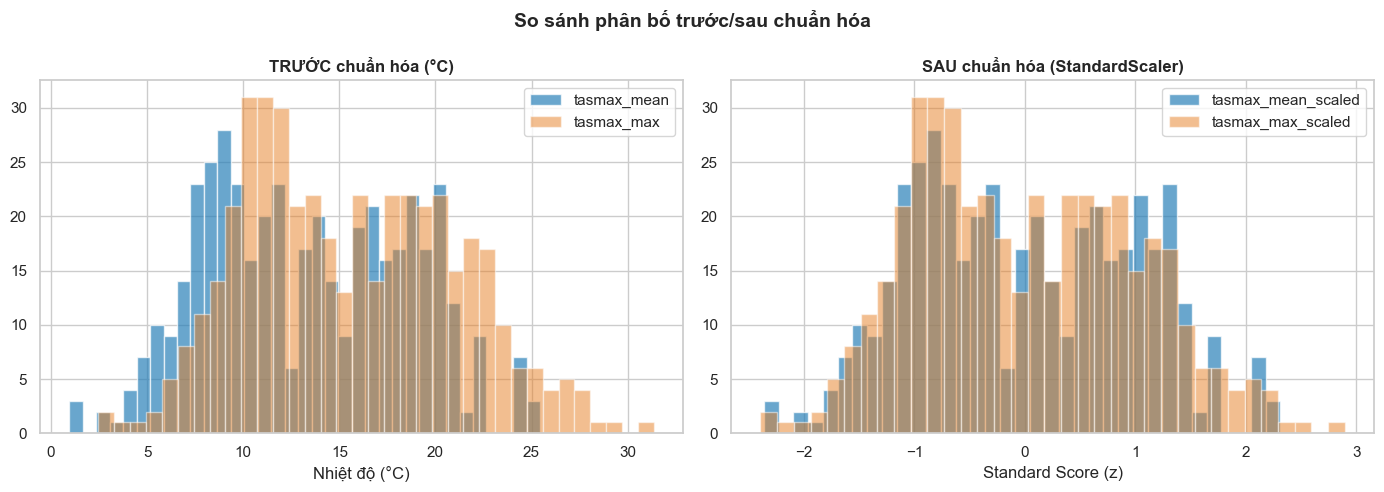

In [20]:
# So sánh trực quan trước/sau chuẩn hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['tasmax_mean_weekly_degC'], bins=35, color='#2980b9', alpha=0.7, label='tasmax_mean')
axes[0].hist(df['tasmax_max_weekly_degC'], bins=35, color='#e67e22', alpha=0.5, label='tasmax_max')
axes[0].set_title('TRƯỚC chuẩn hóa (°C)', fontweight='bold')
axes[0].set_xlabel('Nhiệt độ (°C)')
axes[0].legend()

axes[1].hist(df['tasmax_mean_scaled'], bins=35, color='#2980b9', alpha=0.7, label='tasmax_mean_scaled')
axes[1].hist(df['tasmax_max_scaled'], bins=35, color='#e67e22', alpha=0.5, label='tasmax_max_scaled')
axes[1].set_title('SAU chuẩn hóa (StandardScaler)', fontweight='bold')
axes[1].set_xlabel('Standard Score (z)')
axes[1].legend()

plt.suptitle('So sánh phân bố trước/sau chuẩn hóa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.12 Kiểm tra mất cân bằng (Imbalance Check)

Kiểm tra xem số tuần có **"Surge"** (tử vong cao) chiếm bao nhiêu % tổng dữ liệu.

In [21]:
# Phân bố lớp IsSurge
surge_counts = df['IsSurge'].value_counts()
surge_pct = df['IsSurge'].value_counts(normalize=True) * 100

print('KIỂM TRA MẤT CÂN BẰNG (Imbalance Check)')
print('=' * 50)
print(f'Class 0 (Normal): {surge_counts[0]} tuần ({surge_pct[0]:.1f}%)')
print(f'Class 1 (Surge):  {surge_counts[1]} tuần ({surge_pct[1]:.1f}%)')
print(f'\nTỷ lệ Normal:Surge = {surge_counts[0]/surge_counts[1]:.1f} : 1')

ratio = surge_counts.min() / surge_counts.max()
if ratio < 0.3:
    print(f'\n Dữ liệu MẤT CÂN BẰNG (minority ratio = {ratio:.2f})')
    print('  → Cần xem xét: SMOTE, class_weight, hoặc stratified sampling khi train Classification.')
else:
    print(f'\n Tỷ lệ chấp nhận được (minority ratio = {ratio:.2f})')
    print('  → Với 75th percentile, tỷ lệ ~25/75 là hợp lý cho classification.')

KIỂM TRA MẤT CÂN BẰNG (Imbalance Check)
Class 0 (Normal): 331 tuần (74.9%)
Class 1 (Surge):  111 tuần (25.1%)

Tỷ lệ Normal:Surge = 3.0 : 1

 Tỷ lệ chấp nhận được (minority ratio = 0.34)
  → Với 75th percentile, tỷ lệ ~25/75 là hợp lý cho classification.


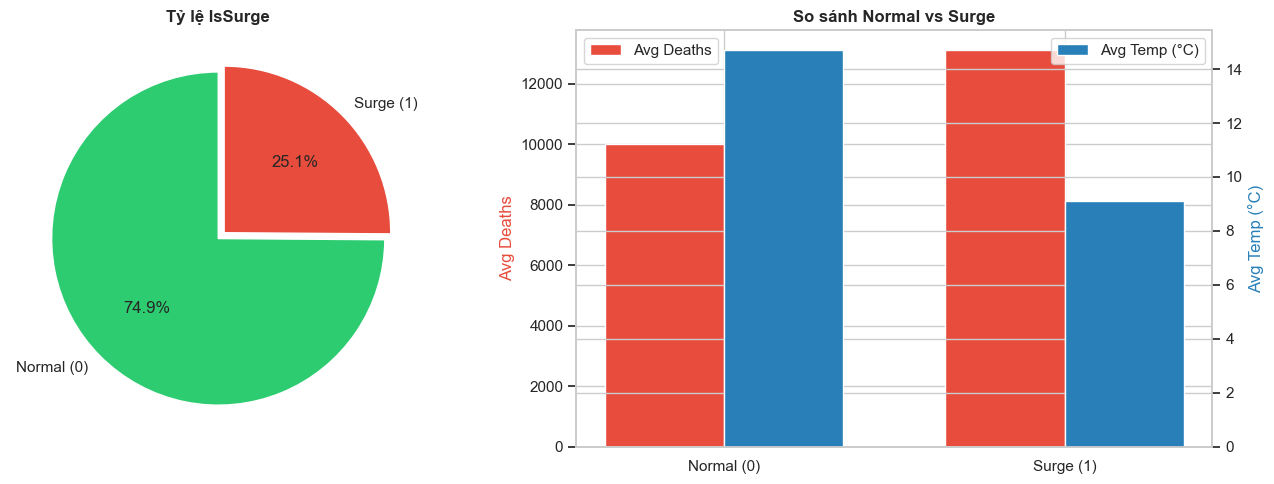


So sánh chi tiết:


,avg_deaths,avg_temp
IsSurge,,
0,10013.50,14.70
1,13106.90,9.10


In [22]:
# Pie chart phân bố IsSurge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(surge_counts.values, labels=['Normal (0)', 'Surge (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=[0, 0.05])
axes[0].set_title('Tỷ lệ IsSurge', fontweight='bold')

# Surge vs Normal: trung bình deaths & temp
surge_compare = df.groupby('IsSurge').agg(
    avg_deaths=('deaths_total', 'mean'),
    avg_temp=('tasmax_mean_weekly_degC', 'mean')
).round(1)

x = np.arange(len(surge_compare))
width = 0.35
bars1 = axes[1].bar(x - width/2, surge_compare['avg_deaths'], width, label='Avg Deaths', color='#e74c3c')
ax2 = axes[1].twinx()
bars2 = ax2.bar(x + width/2, surge_compare['avg_temp'], width, label='Avg Temp (°C)', color='#2980b9')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Normal (0)', 'Surge (1)'])
axes[1].set_ylabel('Avg Deaths', color='#e74c3c')
ax2.set_ylabel('Avg Temp (°C)', color='#2980b9')
axes[1].set_title('So sánh Normal vs Surge', fontweight='bold')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print('\nSo sánh chi tiết:')
surge_compare

## 2.13 Tổng kết chất lượng dữ liệu

In [23]:
print('=' * 65)
print('BÁO CÁO CHẤT LƯỢNG DỮ LIỆU')
print('=' * 65)
print(f'Tổng bản ghi:           {len(df)}')
print(f'Tổng cột (sau xử lý):   {len(df.columns)}')
print(f'Khoảng thời gian:        {df["week_start_mon"].min().date()} → {df["week_start_mon"].max().date()}')
print(f'Missing values:          {df.isnull().sum().sum()}')
print(f'Bản ghi trùng:           {df.duplicated().sum()}')
print(f'Khoảng tử vong:          {df["deaths_total"].min():.0f} – {df["deaths_total"].max():.0f}')
print(f'TB tử vong/tuần:         {df["deaths_total"].mean():.0f}')
print(f'Ngưỡng Surge (P75):      {threshold_75:.0f}')
print(f'Số tuần Surge:           {df["IsSurge"].sum()} ({df["IsSurge"].mean()*100:.1f}%)')
print(f'Khoảng nhiệt độ:         {df["tasmax_mean_weekly_degC"].min():.1f}°C – {df["tasmax_mean_weekly_degC"].max():.1f}°C')
print(f'Tuần nóng > 30°C:        {len(hot_weeks)}')
print(f'Tuần tử vong > 20,000:   {len(high_death_weeks)}')
print(f'\nCác cột trong dataset:')
print(list(df.columns))
print('=' * 65)

BÁO CÁO CHẤT LƯỢNG DỮ LIỆU
Tổng bản ghi:           442
Tổng cột (sau xử lý):   15
Khoảng thời gian:        2016-01-04 → 2024-12-23
Missing values:          0
Bản ghi trùng:           0
Khoảng tử vong:          6825 – 22351
TB tử vong/tuần:         10790
Ngưỡng Surge (P75):      11508
Số tuần Surge:           111 (25.1%)
Khoảng nhiệt độ:         1.0°C – 25.5°C
Tuần nóng > 30°C:        1
Tuần tử vong > 20,000:   2

Các cột trong dataset:
['week_start_sat', 'week_start_mon', 'week_end', 'deaths_total', 'tasmax_mean_weekly_degC', 'tasmax_max_weekly_degC', 'year', 'month', 'week_of_year', 'quarter', 'season', 'temp_range_weekly', 'IsSurge', 'tasmax_mean_scaled', 'tasmax_max_scaled']


## 2.14 Lưu Dataset đã xử lý

In [24]:
# Loại bỏ 2 cột scaled (chỉ dùng cho EDA) trước khi lưu model
if 'tasmax_mean_scaled' in df.columns:
    df_final = df.drop(columns=['tasmax_mean_scaled', 'tasmax_max_scaled'])
else:
    df_final = df.copy()

# Lưu dataset đã chuẩn bị cho các notebook tiếp theo
df_final.to_csv('uk_weather_health_weekly_CLEANED.csv', index=False)
print(f' Dataset đã lưu: {df_final.shape[0]} rows × {df_final.shape[1]} columns')
print(f'   File: uk_weather_health_weekly_CLEANED.csv')
df_final.head()

 Dataset đã lưu: 442 rows × 15 columns
   File: uk_weather_health_weekly_CLEANED.csv


,week_start_sat,week_start_mon,week_end,deaths_total,tasmax_mean_weekly_degC,tasmax_max_weekly_degC,year,month,week_of_year,quarter,season,temp_range_weekly,IsSurge,tasmax_mean_scaled,tasmax_max_scaled
0,2016-01-02,2016-01-04,2016-01-08,13045.00,7.36,8.84,2016,1,1,1,Winter,1.48,1,-1.14,-1.23
1,2016-01-09,2016-01-11,2016-01-15,11501.00,5.13,7.14,2016,1,2,1,Winter,2.00,0,-1.57,-1.54
2,2016-01-16,2016-01-18,2016-01-22,11473.00,5.36,10.23,2016,1,3,1,Winter,4.87,0,-1.52,-0.97
3,2016-01-23,2016-01-25,2016-01-29,11317.00,11.17,13.15,2016,1,4,1,Winter,1.99,0,-0.41,-0.44
4,2016-01-30,2016-02-01,2016-02-05,11052.00,8.78,11.27,2016,2,5,1,Winter,2.49,0,-0.87,-0.78


---
*Trước: [1. Business Understanding](./1.%20Business%20Understanding%20and%20Analysis.ipynb)* | *Tiếp: [3. Data Analysis with SQL](./3.%20Data%20Analysis%20with%20SQL.ipynb)*